<a href="https://colab.research.google.com/github/ArcasHH/ML/blob/main/F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    !wget -q -O requirements.txt https://raw.githubusercontent.com/ArcasHH/ML/main/requirements.txt
    !pip install -q -r requirements.txt

In [2]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
dataset = pd.read_csv('https://raw.githubusercontent.com/ArcasHH/ML/main/ff.csv', 
                      header=None, 
                      names=['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'])
#dataset.sample(10, random_state=0)

In [4]:
#print('Размер выборки составляет l={} объектов.'.format(len(dataset)))

In [5]:
#sns.pairplot(dataset, hue='area', height=7)
#plt.show()

In [6]:
Y=dataset[['area']]
X=dataset[['X',	'Y',	'FFMC',	'DMC',	'DC',	'ISI',	'temp',	'RH',	'wind',	'rain']]
print(Y)
print(X)
w = np.linalg.inv(X.T@X)@X.T@Y
print(w)

      area
0     0.00
1     0.00
2     0.00
3     0.00
4     0.00
..     ...
512   6.44
513  54.29
514  11.16
515   0.00
516   0.00

[517 rows x 1 columns]
     X  Y  FFMC    DMC     DC   ISI  temp  RH  wind  rain
0    7  5  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0
1    7  4  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0
2    7  4  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0
3    8  6  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2
4    8  6  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0
..  .. ..   ...    ...    ...   ...   ...  ..   ...   ...
512  4  3  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0
513  2  4  81.6   56.7  665.6   1.9  21.9  71   5.8   0.0
514  7  4  81.6   56.7  665.6   1.9  21.2  70   6.7   0.0
515  1  4  94.4  146.0  614.7  11.3  25.6  42   4.0   0.0
516  6  3  79.5    3.0  106.7   1.1  11.8  31   4.5   0.0

[517 rows x 10 columns]
       area
0  1.913487
1  0.522545
2 -0.101162
3  0.079401
4 -0.003287
5 -0.681862
6  0.777438
7 -0.242524
8  1.524466
9 -

In [7]:
w.to_numpy()

array([[ 1.91348684e+00],
       [ 5.22544847e-01],
       [-1.01161531e-01],
       [ 7.94014782e-02],
       [-3.28720286e-03],
       [-6.81861889e-01],
       [ 7.77438236e-01],
       [-2.42524046e-01],
       [ 1.52446642e+00],
       [-3.29633472e+00]])

In [8]:
X

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [9]:
Y=np.log(1+Y)
Y

,area
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
512,2.006871
513,4.012592
514,2.498152
515,0.000000


In [10]:
w = np.linalg.inv(X.T@X)@X.T@Y
w = w.to_numpy()

In [11]:
#sns.displot(dataset, x = "area")

In [12]:
f = X@w
#print(X@w)
print(Y)
#f.shape
f = f.to_numpy()

         area
0    0.000000
1    0.000000
2    0.000000
3    0.000000
4    0.000000
..        ...
512  2.006871
513  4.012592
514  2.498152
515  0.000000
516  0.000000

[517 rows x 1 columns]


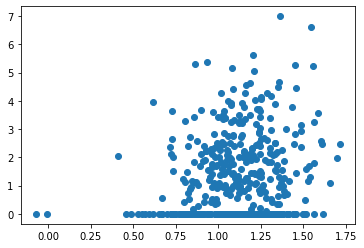

In [13]:
plt.scatter(f , Y)
plt.show()